# Hard Istance Max Cut with different annealing methods

#### Imports

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import get_driver_hamiltonian,get_longitudinal_hamiltonian,computational_basis
from src.schedule_utils import SchedulerModel,Schedule
from ManyBodyQutip.qutip_class import SpinOperator 

## Initialization of the target Hamiltonian

#### Hyperapameters

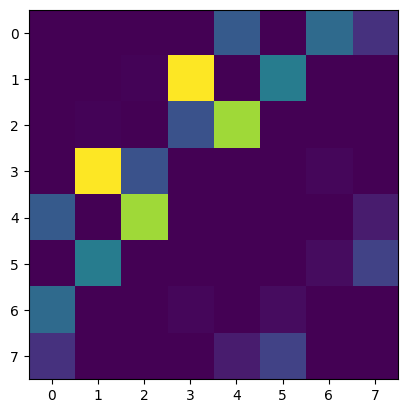

In [12]:
#### create istances on networkx
nqubits = 8

basis=computational_basis(nqubits)
graph_instance = nx.random_regular_graph(d=3, n=nqubits)

# Assign random weights in [0,1]
for u, v in graph_instance.edges():
    graph_instance[u][v]['weight'] = np.random.uniform(0, 1)
    
jij = nx.to_numpy_array(graph_instance)  # unweighted adjacency matrix

plt.imshow(jij)
plt.show()

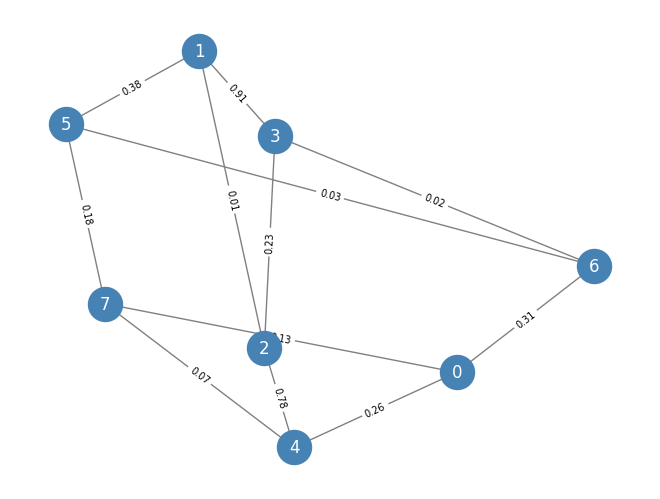

In [13]:

pos = nx.spring_layout(graph_instance, seed=42)
nx.draw(graph_instance, pos, with_labels=True, node_color='steelblue',
        edge_color='gray', node_size=600, font_color='white')

# draw edge weights
edge_labels = {(u,v): f"{graph_instance[u][v]['weight']:.2f}" for u,v in graph_instance.edges()}
nx.draw_networkx_edge_labels(graph_instance, pos, edge_labels=edge_labels, font_size=7)

plt.show()

#### Hamiltonian Initialization

In [14]:
nqubits=jij.shape[0]

target_hamiltonian=get_longitudinal_hamiltonian(jij)
driver_hamiltonian=get_driver_hamiltonian(nqubits=nqubits)



#### Analysis of the spectrum of the target hamiltonian

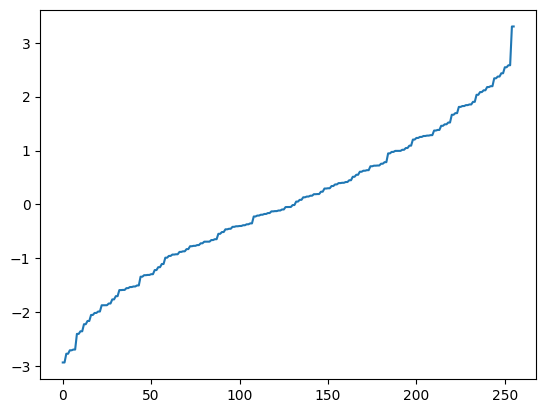

[-2.93334199+0.j -2.93334199+0.j -2.77132383+0.j -2.77132383+0.j] (-2.7713238337791966+0j) [0 0 0 1 1 1 1 0] [0 1 1 0 0 0 1 1]


In [15]:
values=target_hamiltonian.diagonal()

spectrum_target_hamiltonian=np.sort(values)
eigenstates_target_hamiltonian=basis[np.argsort(values)]

plt.plot(spectrum_target_hamiltonian)
plt.show()

print(spectrum_target_hamiltonian[:4],spectrum_target_hamiltonian[2],eigenstates_target_hamiltonian[0],eigenstates_target_hamiltonian[2])

#### Time evolution

In [16]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels    = 10
tau        = 10
time_steps = int(10 * tau)
time       = np.linspace(0, tau, time_steps)
delta_t    = time[1] - time[0]

In [18]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)


# ── initialization ────────────────────────────────────────────────────────────
spectrum            = np.zeros((time_steps, nlevels))
eigenstates_history = np.zeros((time_steps, dim, nlevels), dtype=complex)
energy              = np.zeros(time_steps)
n_subspaces         = nlevels // 2
probabilities       = np.zeros((time_steps, n_subspaces))

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian + (t / tau) * target_hamiltonian
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)

    # ── diagonalize ───────────────────────────────────────────────────────
    spectrum_t, eigenstates_t = eigsh(hamiltonian_t.astype(complex), which='SA', k=nlevels)
    order              = np.argsort(spectrum_t)
    spectrum[i]        = spectrum_t[order]
    eigenstates_raw    = eigenstates_t[:, order].astype(complex)  # raw — for probabilities

    # overlap
    overlap_t=np.einsum('i,ia->a',psi.conj(),eigenstates_raw)
    for r in range(n_subspaces):
        probabilities[i,r]=np.sum(((overlap_t[r*2:(r+1)*2])*(overlap_t[r*2:(r+1)*2]).conj()))
    energy[i] = np.real(np.vdot(psi, hamiltonian_t @ psi))


print(probabilities[-1])
print(spectrum.shape)
print(time[np.argmin(spectrum[:,2]-spectrum[:,0])],np.min(spectrum[:,2]-spectrum[:,0]))

min_time_gap= time[np.argmin(spectrum[:,2]-spectrum[:,0])]

/tmp/ipykernel_56903/1274001587.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities[i,r]=np.sum(((overlap_t[r*2:(r+1)*2])*(overlap_t[r*2:(r+1)*2]).conj()))


[0.18089672 0.13237487 0.13800265 0.11084722 0.05893093]
(100, 10)
9.595959595959595 0.15824300536474212


In [19]:
# last time step hamiltonian
t_last = time[-1]
hamiltonian_last = (1 - t_last / tau) * driver_hamiltonian + (t_last / tau) * target_hamiltonian

# compute gs subspace from last hamiltonian — not target_hamiltonian
evals_last, evecs_last = eigsh(hamiltonian_last.astype(complex), which='SA', k=4)
order       = np.argsort(evals_last)
evals_last  = evals_last[order]
evecs_last  = evecs_last[:, order]
tol_last    = 1e-3 * np.abs(evals_last[-1] - evals_last[0])
gs_mask     = np.abs(evals_last - evals_last[0]) < tol_last
gs_subspace = evecs_last[:, gs_mask]

print(f'GS degeneracy (last step): {gs_subspace.shape[1]}')
print(f'GS energy (last step):     {evals_last[0]:.6f}')

GS degeneracy (last step): 2
GS energy (last step):     -2.933342


Check the results

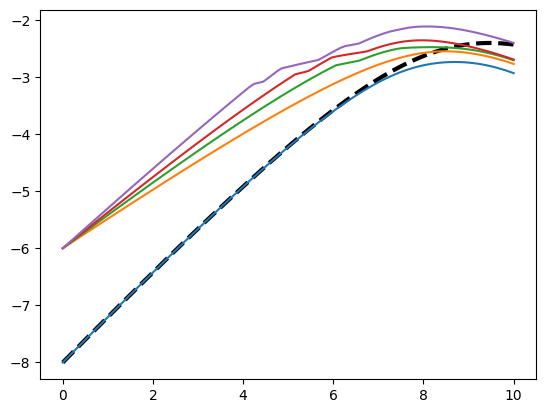

In [20]:

plt.plot(time,energy,color='black',linestyle='--',linewidth=3)
for i in range(spectrum.shape[1]):
    if i%2==0:
        plt.plot(time,spectrum[:,i])

plt.show()

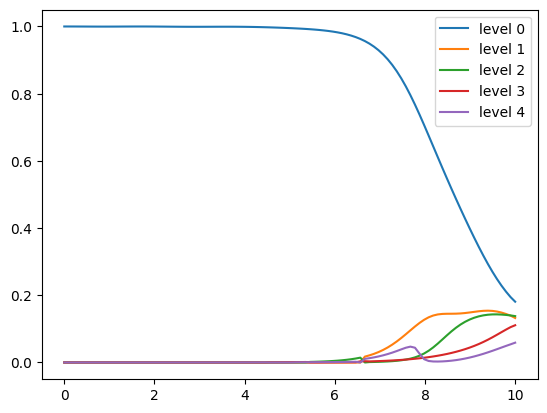

In [21]:
for i in range(nlevels//2):
    plt.plot(time,probabilities[:,i],label=f'level {i}')

plt.legend()
plt.show()

## Optimal Control Method

##### Get Hyperparameters

In [22]:
number_parameters=3
type='F-CRAB'

In [23]:
from scipy.optimize import minimize

model=SchedulerModel(target_hamiltonian=target_hamiltonian,initial_hamiltonian=driver_hamiltonian,tf=tau,nsteps=time_steps,number_of_parameters=number_parameters,type=type,seed=42,reference_hamiltonian=target_hamiltonian,mode='annealing ansatz')



res = minimize(
                    model.forward,
                    model.parameters,
                    method='L-BFGS-B',
                    tol=10**-6,
                    callback=model.callback,
                    options=None,
                    
                )

model.parameters = res.x
energy = model.forward(model.parameters)

-2.5327909668933324
-2.5572410257308515
-2.7063765537519915
-2.7145848270120787
-2.7485687516787074
-2.762118695627489
-2.770337083283242
-2.7800316273623227
-2.820337587021596
-2.848562239415302
-2.8526672678980405
-2.858423820630739
-2.86450487913227
-2.867922315979485
-2.869710590738871
-2.8708077625807955
-2.8717958381819453
-2.872239338778741
-2.87393792180554
-2.8799220166020265
-2.8824412351458966
-2.885230248205094
-2.888751027254182
-2.897885967927902
-2.8986215200366185
-2.8990287628258216
-2.8995486640033454
-2.899786148776529
-2.9036379948732933
-2.903677090918955
-2.9040375397586478
-2.904836488840531
-2.9055560461983827
-2.9058468234234147
-2.90667878528926
-2.907028672037989
-2.9071004913598606
-2.9072500588879815
-2.907294152796732
-2.9104523721131015
-2.91045426060153


#### Jax optimization (optional)

In [60]:
from src.jax_utils import JaxSchedulerModel, JaxTrainer

model = JaxSchedulerModel(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian,
    initial_hamiltonian=driver_hamiltonian,
    reference_hamiltonian=target_hamiltonian,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    mode='annealing ansatz',
    random=True,
)

trainer = JaxTrainer(model, maxiter=1000, tol=1e-6, ftol=1e-9, gtol=1e-6, verbose=True)
results = trainer.run()

h_driver  = results['h_driver']
h_target  = results['h_target']
psi_final = results['psi']
energy    = results['energy']   # already in physical units

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


KeyboardInterrupt: 

#### Check the results

(-0.8470417285148093+2.672376232653259j)


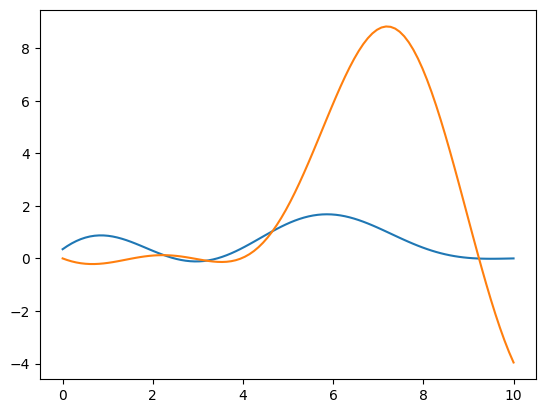

(-2.9104542607861394+0j)


In [24]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear  = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history  = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)

# optimal
h_driver, h_target = model.get_driving()

# initialize the state
_, psi = eigsh(driver_hamiltonian.astype(complex), which='SA', k=1)
psi_init = psi[:, 0].astype(complex)
print(psi_init.dot(h_driver[0]*driver_hamiltonian.dot(psi_init)))

plt.plot(time,h_driver)
plt.plot(time,h_target)
plt.show()





# initialization
psi=psi_init.copy()
psi_history_optimalcontrol=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
for i,t in enumerate(time):
    
    hamiltonian_t=h_driver[i]*driver_hamiltonian+target_hamiltonian*h_target[i]
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    psi_history_optimalcontrol[i]=psi
    #for r in range(nlevels):
    #    probabilities_optimalcontrol[i,r]=(eigenstates_history[i,:,r].conj().T.dot(psi))*np.conjugate((eigenstates_history[i,:,r].conj().T.dot(psi)))

print(psi.conj().dot(target_hamiltonian.dot(psi)))

In [26]:


# initialization
energy_optimal=np.zeros(time_steps)
probabilities_optimalcontrol=np.zeros((time_steps,nlevels//2))
spectrum_optimalcontrol=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_optimalcontrol[i]     
    hamiltonian_t=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau
    values, eigenstates = eigsh(hamiltonian_t, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i]=spectrum_t
    # overlap
    overlap_t=np.einsum('i,ia->a',psi.conj(),eigenstates_t)
    for r in range(n_subspaces):
        probabilities_optimalcontrol[i,r]=np.sum(((overlap_t[r*2:(r+1)*2])*(overlap_t[r*2:(r+1)*2]).conj()).real)
    energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian.dot(psi)))
print(probabilities_optimalcontrol[-1,0])

/tmp/ipykernel_56903/3912910125.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))


10.0
(-2.9104542607861394+0j)
0.9282560793861577


In [27]:
print(spectrum_optimalcontrol[-1])

[-2.93334199 -2.93334199 -2.77132383 -2.77132383 -2.70744962 -2.70744962
 -2.69350532 -2.69350532 -2.4029717  -2.4029717 ]


0
-2.933341990251771
2
-2.7713238337791863
4
-2.7074496208820493
6
-2.693505322185223
8
-2.4029717003240725


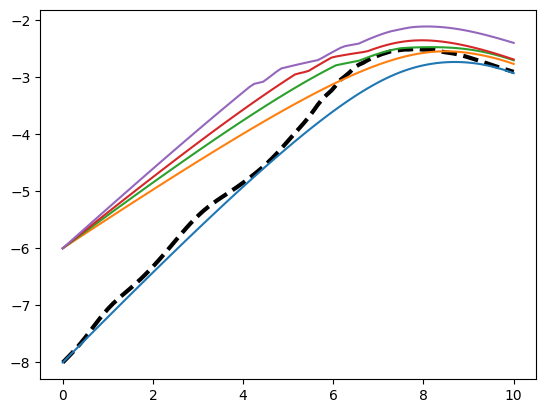

In [28]:

plt.plot(time,energy_optimal,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_optimalcontrol.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum_optimalcontrol[-1,i])
        plt.plot(time,spectrum_optimalcontrol[:,i])

plt.show()

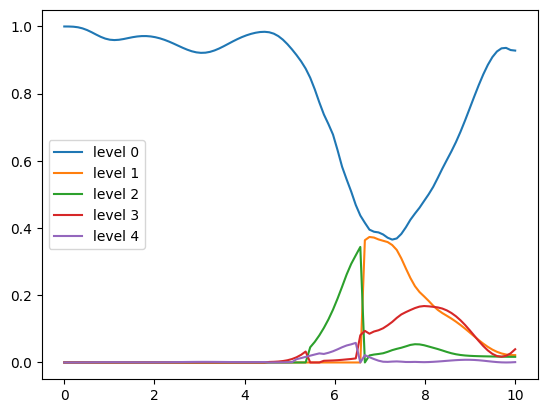

In [29]:
for i in range(nlevels//2):
    plt.plot(time,probabilities_optimalcontrol[:,i],label=f'level {i}')

plt.legend()
plt.show()

## CounterAdiabatic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [30]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term

counteradiabatic_term=get_counteradiabatic_term(driver_hamiltonian=driver_hamiltonian,target_hamiltonian=target_hamiltonian)
catalyst_term=get_unbiased_catalyst_term(nqubits=nqubits)
print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 2048 stored elements and shape (256, 256)>
  Coords	Values
  (0, 1)	-0.7569546039113821j
  (0, 2)	-0.7194629658165081j
  (0, 4)	-1.1842150572755732j
  (0, 8)	-2.2113549165029784j
  (0, 16)	-2.3087634710875955j
  (0, 32)	-2.0322032438566056j
  (0, 64)	-2.5938936615837482j
  (0, 128)	-1.3985990581339212j
  (1, 0)	0.7569546039113821j
  (1, 3)	-0.7194629658165086j
  (1, 5)	-0.4602785676881269j
  (1, 9)	-1.93850013411249j
  (1, 17)	-2.3087634710875955j
  (1, 33)	-2.032203243856605j
  (1, 65)	-2.5938936615837482j
  (1, 129)	-0.8814811222890921j
  (2, 0)	0.7194629658165081j
  (2, 3)	-0.7569546039113826j
  (2, 6)	-1.0627160303828327j
  (2, 10)	-2.2113549165029784j
  (2, 18)	-2.241169822091539j
  (2, 34)	-2.0322032438566056j
  (2, 66)	-2.5938936615837482j
  (2, 130)	-0.14876580238970227j
  (3, 1)	0.7194629658165086j
  :	:
  (252, 254)	0.7194629658165086j
  (253, 125)	-0.14876580238970227j
  (253, 189)	-2.5938936615837482j
  (253, 

Tayloring the catalyst around the minimum gap

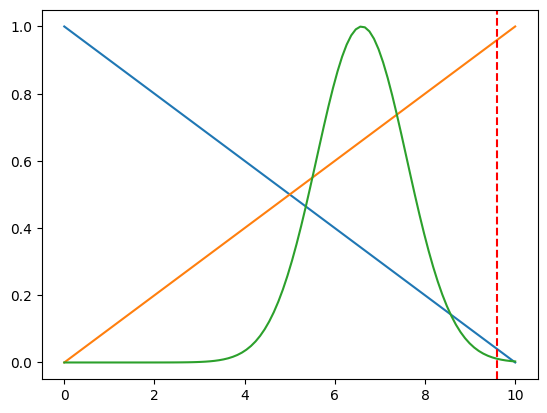

In [31]:
plt.plot(time,(1-time/tau))
plt.plot(time,time/tau)
sigma = 0.1   # width — tune this
catalyst_schedule = np.exp(-0.5 * ((time / tau - (min_time_gap-3)/tau) / sigma) ** 2)
plt.axvline(x=min_time_gap, color='red', linestyle='--', label='Min Gap Time')
plt.plot(time,catalyst_schedule)
plt.show()

In [47]:
from scipy.sparse.linalg import eigsh,expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)


# initialization

psi=psi_init
psi_history_catalyst=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_catalyst=np.zeros((time_steps,nlevels))
energy_catalyst=np.zeros(time_steps)
for i,t in enumerate(time):
    
    hamiltonian_t=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau+(1/tau)*counteradiabatic_term
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_catalyst[i]=spectrum_t
    energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_catalyst[i]=psi


/tmp/ipykernel_56903/2134716794.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [48]:

# initialize the state


# initialization
energy_catalyst_linear_hamiltonian=np.zeros(time_steps)
probabilities_catalyst=np.zeros((time_steps,nlevels//2))
for i,t in enumerate(time):
    psi=psi_history_catalyst[i]     
    hamiltonian_t_linear=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    overlap_t=np.einsum('i,ia->a',psi.conj(),eigenstates_t)
    for r in range(n_subspaces):
        probabilities_catalyst[i,r]=np.sum(((overlap_t[r*2:(r+1)*2])*(overlap_t[r*2:(r+1)*2]).conj()).real)
    
    energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian.dot(psi)))
print(probabilities_catalyst[-1,0])

/tmp/ipykernel_56903/4061078792.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


10.0
(-2.5440562084638563+2.7755575615628914e-17j)
0.2515464150062115


##### Results of the unbiased catalyst

0
-2.9333419902517717
2
-2.771323833779189
4
-2.7074496208820538
6
-2.6935053221852225
8
-2.402971700324065


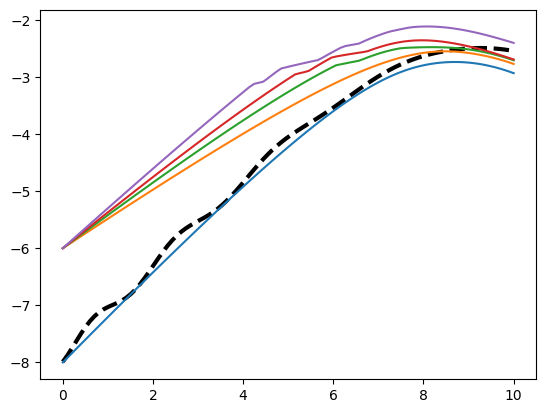

0
-3.0492875849308505
2
-2.8903518580515146
4
-2.803517918786827
6
-2.799838680514051
8
-2.4980459254058722


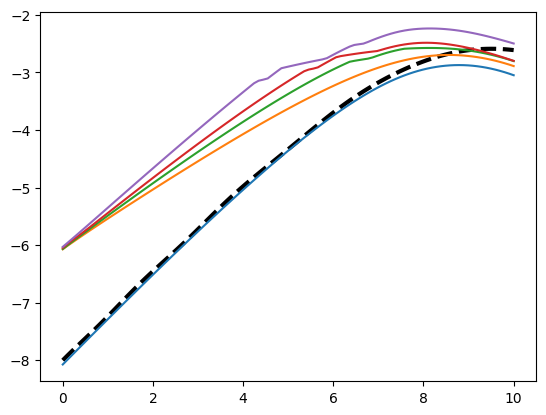

In [49]:

plt.plot(time,energy_catalyst_linear_hamiltonian,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum[-1,i])
        plt.plot(time,spectrum[:,i])

plt.show()

plt.plot(time,energy_catalyst,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum_catalyst[-1,i])
        plt.plot(time,spectrum_catalyst[:,i])

plt.show()


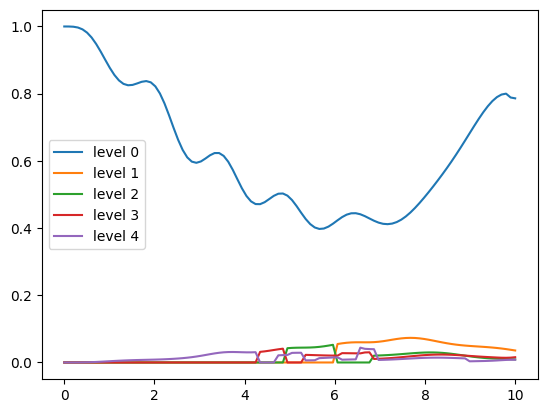

In [95]:
for i in range(nlevels//2):
    plt.plot(time,probabilities_catalyst[:,i],label=f'level {i}')

plt.legend()
plt.show()

## Catalyst Term

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [76]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term
from ManyBodyQutip.qutip_class import SpinOperator

counteradiabatic_term=get_counteradiabatic_term(driver_hamiltonian=driver_hamiltonian,target_hamiltonian=target_hamiltonian)
#catalyst_term=get_unbiased_catalyst_term(nqubits=nqubits)
catalyst_term=SpinOperator(index=[('x',0,'x',nqubits-2)],coupling=[1.],size=nqubits).qutip_op.data_as('csr_matrix')

print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 2048 stored elements and shape (256, 256)>
  Coords	Values
  (0, 1)	-0.7569546039113821j
  (0, 2)	-0.7194629658165081j
  (0, 4)	-1.1842150572755732j
  (0, 8)	-2.2113549165029784j
  (0, 16)	-2.3087634710875955j
  (0, 32)	-2.0322032438566056j
  (0, 64)	-2.5938936615837482j
  (0, 128)	-1.3985990581339212j
  (1, 0)	0.7569546039113821j
  (1, 3)	-0.7194629658165086j
  (1, 5)	-0.4602785676881269j
  (1, 9)	-1.93850013411249j
  (1, 17)	-2.3087634710875955j
  (1, 33)	-2.032203243856605j
  (1, 65)	-2.5938936615837482j
  (1, 129)	-0.8814811222890921j
  (2, 0)	0.7194629658165081j
  (2, 3)	-0.7569546039113826j
  (2, 6)	-1.0627160303828327j
  (2, 10)	-2.2113549165029784j
  (2, 18)	-2.241169822091539j
  (2, 34)	-2.0322032438566056j
  (2, 66)	-2.5938936615837482j
  (2, 130)	-0.14876580238970227j
  (3, 1)	0.7194629658165086j
  :	:
  (252, 254)	0.7194629658165086j
  (253, 125)	-0.14876580238970227j
  (253, 189)	-2.5938936615837482j
  (253, 

Tayloring the catalyst around the minimum gap

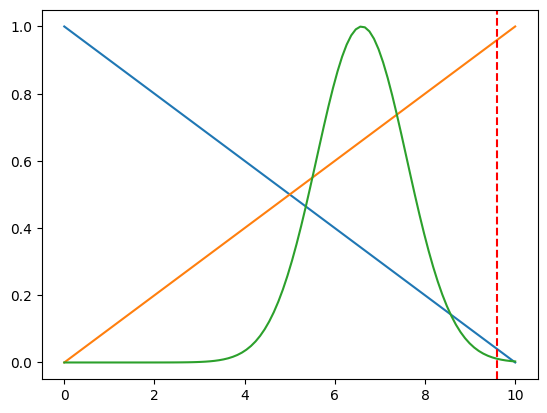

In [81]:
plt.plot(time,(1-time/tau))
plt.plot(time,time/tau)
sigma = 0.1   # width — tune this
catalyst_schedule = np.exp(-0.5 * ((time / tau - (min_time_gap-3)/tau) / sigma) ** 2)
plt.axvline(x=min_time_gap, color='red', linestyle='--', label='Min Gap Time')
plt.plot(time,catalyst_schedule)
plt.show()

In [ ]:
from scipy.sparse.linalg import eigsh,expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)


# initialization

psi=psi_init
psi_history_catalyst=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_catalyst=np.zeros((time_steps,nlevels))
energy_catalyst=np.zeros(time_steps)
for i,t in enumerate(time):
    
    hamiltonian_t=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau-catalyst_schedule[i]*catalyst_term
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_catalyst[i]=spectrum_t
    energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_catalyst[i]=psi


ValueError: matmul: dimension mismatch with signature (n,k=256),(k=100,1?)->(n,1?)

In [79]:

# initialize the state


# initialization
energy_catalyst_linear_hamiltonian=np.zeros(time_steps)
probabilities_catalyst=np.zeros((time_steps,nlevels//2))
for i,t in enumerate(time):
    psi=psi_history_catalyst[i]     
    hamiltonian_t_linear=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    overlap_t=np.einsum('i,ia->a',psi.conj(),eigenstates_t)
    for r in range(n_subspaces):
        probabilities_catalyst[i,r]=np.sum(((overlap_t[r*2:(r+1)*2])*(overlap_t[r*2:(r+1)*2]).conj()).real)
    
    energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian.dot(psi)))
print(probabilities_catalyst[-1,0])

/tmp/ipykernel_56903/4061078792.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


10.0
(-2.4091362796914204-2.7755575615628914e-17j)
0.19184243959787028


##### Results of the unbiased catalyst

0
-2.9333419902517717
2
-2.771323833779189
4
-2.7074496208820538
6
-2.6935053221852225
8
-2.402971700324065


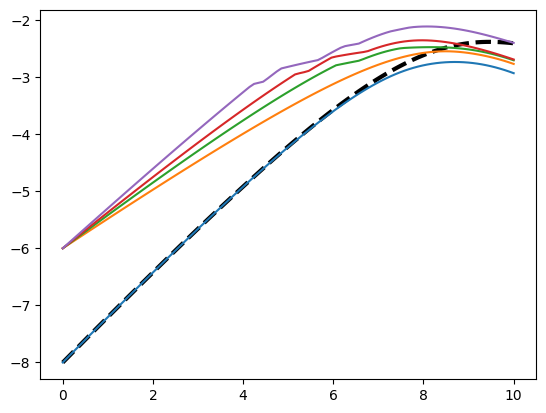

0
-2.9333419902517868
2
-2.771323833779191
4
-2.707449620882047
6
-2.6935053221852314
8
-2.4029717003240614


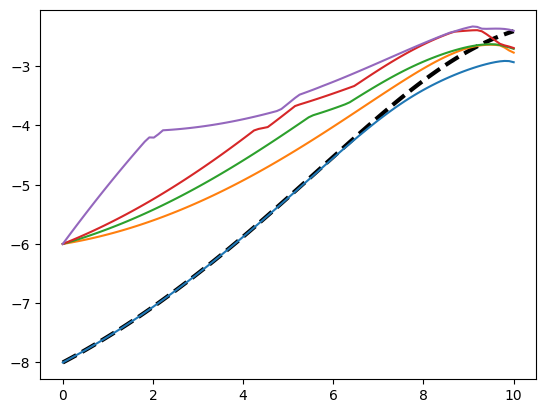

In [80]:

plt.plot(time,energy_catalyst_linear_hamiltonian,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum[-1,i])
        plt.plot(time,spectrum[:,i])

plt.show()

plt.plot(time,energy_catalyst,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum_catalyst[-1,i])
        plt.plot(time,spectrum_catalyst[:,i])

plt.show()


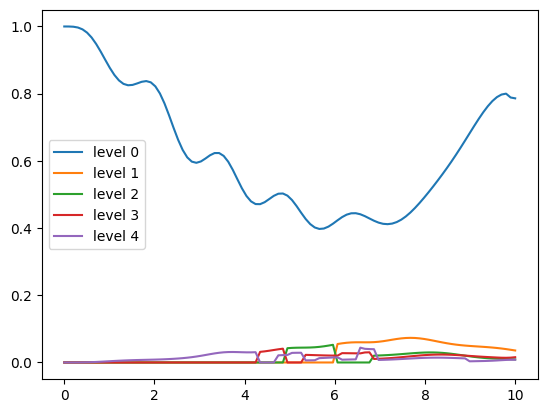

In [ ]:
for i in range(nlevels//2):
    plt.plot(time,probabilities_catalyst[:,i],label=f'level {i}')

plt.legend()
plt.show()